Aggregating crime by each month


In [1]:
import os
import pandas as pd
from pathlib import Path

project_root = Path(os.getcwd()).resolve().parent
data_path = project_root / "data" / "processed" / "crime_data_processed.csv"
df = pd.read_csv(data_path)

df["Crime Count"] = pd.to_numeric(df["Crime Count"], errors="coerce")

# Aggregate to State-Year-Month level
cluster_df = (
    df.groupby(["State", "Year", "Month"])
    .agg(
        total_crime=("Crime Count", "sum"),
        unique_crimes=("Crime Description", "nunique"),
    )
    .reset_index()
)

print(cluster_df.head())

            State  Year  Month  total_crime  unique_crimes
0  Andhra Pradesh  2020      1         14.0             12
1  Andhra Pradesh  2020      2          8.0              7
2  Andhra Pradesh  2020      3         14.0              8
3  Andhra Pradesh  2020      4          7.0              7
4  Andhra Pradesh  2020      5         18.0             11


In [2]:
# Sample output of above block
#       State        Year   Month      total_crime  unique_crimes
# 0  Andhra Pradesh  2020      1         14.0             12
# 1  Andhra Pradesh  2020      2          8.0              7
# 2  Andhra Pradesh  2020      3         14.0              8
# 3  Andhra Pradesh  2020      4          7.0              7
# 4  Andhra Pradesh  2020      5         18.0             11

Encode categorical features


In [3]:
from sklearn.preprocessing import LabelEncoder

df_model = df.copy()

state_encoder = LabelEncoder()
crime_encoder = LabelEncoder()

# Converting the STATE | CRIME DESC to numericals
df_model["State"] = state_encoder.fit_transform(df_model["State"])
df_model["Crime Description"] = crime_encoder.fit_transform(
    df_model["Crime Description"]
)

print(df_model.head())

   State  Year  Month  Crime Description  Crime Count
0      0  2020      1                  2          1.0
1      0  2020      1                  3          2.0
2      0  2020      1                  4          2.0
3      0  2020      1                  5          1.0
4      0  2020      1                  6          1.0


Data Visualization Through Distribution


count    12608.000000
mean         3.185121
std          2.500320
min          1.000000
25%          1.000000
50%          2.000000
75%          4.000000
max         21.000000
Name: Crime Count, dtype: float64


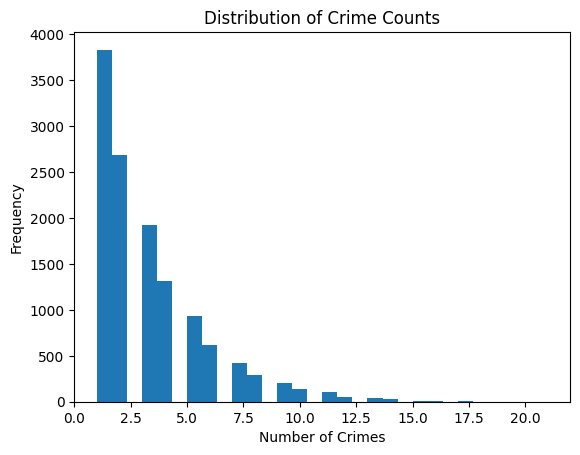

In [4]:
import matplotlib.pyplot as plt

# This Data Visualization to find where the hightest number of data is present in range.

# Check the distribution of Target var [Crime Count]
print(df_model["Crime Count"].describe())

plt.hist(df_model["Crime Count"], bins=30)
plt.title("Distribution of Crime Counts")
plt.xlabel("Number of Crimes")
plt.ylabel("Frequency")
plt.show()

In [5]:
data_check = pd.crosstab(df_model['State'], df_model['Month'])

# Print the grid
print(data_check)

Month   1    2    3    4    5    6    7   8   9   10  11  12
State                                                       
0       54   44   44   44   50   49   44  44  38  34  41  42
1       48   49   49   52   42   43   50  36  33  40  43  41
2      101  103  105  104  104  104  103  83  83  82  82  83
3      103  101   93   95   99   96   98  79  79  81  80  79
4       25   30   31   25   29   32   22  23  26  21  23  16
5       26   20   31   27   44   28   28  24  22  26  28  24
6      100  101  100  100  101  101   94  76  78  81  82  81
7       74   65   72   76   76   75   73  59  65  57  60  64
8      105  105  105  105  105  105  105  84  84  84  84  84
9       57   44   48   45   50   48   48  41  43  43  37  44
10      75   76   82   78   77   78   77  67  57  60  63  60
11      98   93   94  100   91   87   98  72  73  76  75  76
12      94   98   99   99   99   94   96  80  77  81  80  76
13     104  102  104   99  103  104  105  81  82  83  81  81
14      89   86  100   9

Trainer SVR - SUPPORT VECTOR REGRESSION (For Prediction)


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error


df_clean = df.drop_duplicates().copy().dropna()
df_clean = df_clean.sort_values(by=['State', 'Crime Description', 'Year', 'Month'])

grouper = df_clean.groupby(['State', 'Crime Description'])['Crime Count']

df_clean['Lag_1'] = grouper.shift(1)  # Count last month
df_clean['Lag_3'] = grouper.shift(3)  # Count 3 months ago
df_clean['Rolling_Mean_3'] = grouper.transform(lambda x: x.shift(1).rolling(3).mean())

df_clean = df_clean.dropna()

train_df = df_clean[(df_clean['Year'] >= 2020) & (df_clean['Year'] <= 2023)]

X_train = train_df[['State', 'Year', 'Month', 'Crime Description', 'Lag_1', 'Lag_3', 'Rolling_Mean_3']]
y_train = train_df['Crime Count']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), 
         ['State', 'Crime Description']),
        ('num', StandardScaler(), 
         ['Year', 'Month', 'Lag_1', 'Lag_3', 'Rolling_Mean_3'])
    ]
)

svr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', SVR(kernel='rbf', C=100, gamma=0.05, epsilon=0.2))
])

model = TransformedTargetRegressor(
    regressor=svr_pipeline,
    transformer=StandardScaler() 
)

print(f"Training SVR on {len(X_train)} rows from 2020-2023...")
model.fit(X_train, y_train)
print("Training Complete.")

preds = model.predict(X_train)
mse = mean_squared_error(y_train, preds)
print(f"Training MSE: {mse:.2f}")

Training SVR on 10034 rows from 2020-2023...
Training Complete.
Training MSE: 1.91


Prediction Testing


In [7]:
""" The code below generated prediction for the whole year, so to predict it needs previous data 
    for year 2024 - it needs 2023 data of last maonth atleast.
 """

' The code below generated prediction for the whole year, so to predict it needs previous data \n    for year 2024 - it needs 2023 data of last maonth atleast.\n '

In [ ]:
import pandas as pd
import numpy as np

history_df = df[df['Year'] <= 2023].copy().sort_values(['State', 'Crime Description', 'Year', 'Month'])

# Get all unique State-Crime pairs
unique_combos = df[['State', 'Crime Description']].drop_duplicates()

forecast_rows = []

print("Generating full 2024 lookup table (Recursive)...")

for month in range(1, 13):

    this_month_input = unique_combos.copy()
    this_month_input['Year'] = 2024
    this_month_input['Month'] = month
    this_month_input['Crime Count'] = 0 

    temp_df = pd.concat([history_df, this_month_input], ignore_index=True)
    temp_df = temp_df.sort_values(['State', 'Crime Description', 'Year', 'Month'])
    
    grouper = temp_df.groupby(['State', 'Crime Description'])['Crime Count']
    temp_df['Lag_1'] = grouper.shift(1)
    temp_df['Lag_3'] = grouper.shift(3)
    temp_df['Rolling_Mean_3'] = grouper.transform(lambda x: x.shift(1).rolling(3).mean())
    
    X_pred = temp_df[
        (temp_df['Year'] == 2024) & 
        (temp_df['Month'] == month)
    ].copy()
    
    # Handle NaNs
    features = ['State', 'Year', 'Month', 'Crime Description', 'Lag_1', 'Lag_3', 'Rolling_Mean_3']
    X_pred[features] = X_pred[features].fillna(0)
    
    preds = model.predict(X_pred[features])
    
    # Clean up for +ve Values
    preds = [max(0, int(round(p))) for p in preds]
    
    X_pred['Crime Count'] = preds
    forecast_rows.append(X_pred)
    
    # Add to history so next month can see these predictions
    history_df = pd.concat([history_df, X_pred[['State', 'Crime Description', 'Year', 'Month', 'Crime Count']]], ignore_index=True)
# SAVE THE LOOKUP TABLE
global_forecast = pd.concat(forecast_rows, ignore_index=True)
print(f"Done! Lookup Table Ready with {len(global_forecast)} rows.")
history_df.to_csv(project_root / "data" / "processed" / "crime_data_predicted_nb.csv", index=False)


Generating full 2024 lookup table (Recursive)...
Done! Lookup Table Ready with 3780 rows.


In [1]:
print(global_forecast)

NameError: name 'global_forecast' is not defined

In [10]:
def predict_crime_for_all_states(year, month, crime_type):
    """
    Takes Year, Month, and Crime Type.
    Returns the predicted count for EVERY state.
    """
    if 'global_forecast' not in globals():
        return pd.DataFrame([{"Error": "Please run the 'Lookup Table' generator code first."}])
    
    mask = (
        (global_forecast['Year'] == year) & 
        (global_forecast['Month'] == month) &
        (global_forecast['Crime Description'] == crime_type)
    )
    result_df = global_forecast[mask].copy()
    
    if result_df.empty:
        return pd.DataFrame([{"Error": f"No data found for '{crime_type}' in {month}/{year}. Check spelling."}])
    
    output = result_df[['State', 'Crime Count']].rename(
        columns={'Crime Count': 'Predicted Count'}
    )
    
    return output.sort_values(by='Predicted Count', ascending=False).reset_index(drop=True)


print("\n--- Prediction: Theft (Sep 2024) ---")
print(predict_crime_for_all_states(2024, 1, "ROBBERY").head(10))

print("\n--- Prediction: Arson (Jan 2024) ---")
print(predict_crime_for_all_states(2024, 1, "ARSON").head(15))


--- Prediction: Theft (Sep 2024) ---
            State  Predicted Count
0     Maharashtra                9
1       Karnataka                5
2         Gujarat                4
3       Telangana                4
4   Uttar Pradesh                4
5       Rajasthan                4
6           Delhi                4
7      Tamil Nadu                3
8          Punjab                3
9  Andhra Pradesh                3

--- Prediction: Arson (Jan 2024) ---
              State  Predicted Count
0       Maharashtra               15
1         Karnataka                6
2           Gujarat                5
3         Telangana                5
4     Uttar Pradesh                5
5        Tamil Nadu                4
6             Delhi                4
7       West Bengal                4
8            Punjab                3
9    Andhra Pradesh                2
10            Bihar                2
11  Jammu & Kashmir                2
12          Haryana                2
13        Rajasthan  

In [11]:
import os
import joblib

model_path = project_root / "models"
os.makedirs(model_path, exist_ok=True)

joblib.dump(model, model_path / "svr_model.pkl")
# joblib.dump(scaler_X, model_path / "scaler_svr.pkl")
joblib.dump(state_encoder, model_path / "state_encoder.pkl")
joblib.dump(crime_encoder, model_path / "crime_encoder.pkl")

print("All files saved successfully in 'models/' folder!")

All files saved successfully in 'models/' folder!
